# k6 Metrics Visualization

Set `RESULTS_ROOT` to auto-discover all runs, or populate `METRIC_FILES` with explicit `(label, path)` pairs.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.4

In [2]:
RESULTS_ROOT = "results"
METRIC_FILES = []  # [(label, path), ...] - overrides auto-discovery

In [3]:
def load_metrics(path, metrics=None, label=None):
    print(f"Loading: {path}")

    chunks = []
    total_rows = 0
    kept_rows = 0

    for i, chunk in enumerate(pd.read_json(path, lines=True, chunksize=50_000)):
        total_rows += len(chunk)

        chunk = chunk[chunk["type"] == "Point"]

        if metrics is not None:
            chunk = chunk[chunk["metric"].isin(metrics)]

        kept_rows += len(chunk)

        if chunk.empty:
            continue

        exp = pd.DataFrame(chunk["data"].tolist())
        exp = exp[["time", "value"]]  # drop tags early

        exp["metric"] = chunk["metric"].values
        exp["time"] = pd.to_datetime(exp["time"], utc=True)

        # 👉 ADD LABEL HERE
        if label is not None:
            exp["label"] = label

        chunks.append(exp)

        if i % 10 == 0:
            print(f"  processed {total_rows:,} rows...")

    if not chunks:
        print("  no matching data found")
        return pd.DataFrame()

    df = pd.concat(chunks, ignore_index=True)
    df = df.sort_values("time").reset_index(drop=True)
    df["time_sec"] = (df["time"] - df["time"].min()).dt.total_seconds()

    print(f"  done: kept {kept_rows:,} / {total_rows:,} rows")

    return df

In [4]:
from pathlib import Path

if METRIC_FILES:
    files = [(label, Path(p)) for label, p in METRIC_FILES]
else:
    files = []
    for fp in sorted(Path(RESULTS_ROOT).rglob("metrics.json")):
        parts = fp.parts
        label = "/".join(parts[-5:-1])
        files.append((label, fp))

In [5]:
TARGET_METRICS = ["http_req_duration","http_reqs"]

runs = {
    "direct / http":   load_metrics("results/storage_direct_ping/http/stress/20260422-143755/metrics.json", TARGET_METRICS, "direct / http"),
    "direct / https":  load_metrics("results/storage_direct_ping/https/stress/20260422-152133/metrics.json", TARGET_METRICS, "direct / https"),
    "direct / mtls":   load_metrics("results/storage_direct_ping/mtls/stress/20260422-165801/metrics.json", TARGET_METRICS, "direct / mtls"),
    "gateway / http":  load_metrics("results/gateway_storage_ping/http/stress/20260422-142825/metrics.json", TARGET_METRICS, "gateway / http"),
    "gateway / https": load_metrics("results/gateway_storage_ping/https/stress/20260422-150256/metrics.json", TARGET_METRICS, "gateway / https"),
    "gateway / mtls":  load_metrics("results/gateway_storage_ping/mtls/stress/20260422-160545/metrics.json", TARGET_METRICS, "gateway / mtls"),
}

Loading: results/storage_direct_ping/http/stress/20260422-143755/metrics.json
  processed 50,000 rows...
  processed 550,000 rows...
  processed 1,050,000 rows...
  processed 1,550,000 rows...
  processed 2,050,000 rows...
  processed 2,550,000 rows...
  processed 3,050,000 rows...
  processed 3,550,000 rows...
  processed 4,050,000 rows...
  processed 4,550,000 rows...
  processed 5,050,000 rows...
  processed 5,550,000 rows...
  processed 6,050,000 rows...
  processed 6,550,000 rows...
  processed 7,050,000 rows...
  processed 7,550,000 rows...
  processed 8,050,000 rows...
  processed 8,550,000 rows...
  processed 9,050,000 rows...
  processed 9,550,000 rows...
  processed 10,050,000 rows...
  processed 10,550,000 rows...
  processed 11,050,000 rows...
  processed 11,550,000 rows...
  processed 12,050,000 rows...
  processed 12,550,000 rows...
  processed 13,050,000 rows...
  processed 13,550,000 rows...
  processed 14,050,000 rows...
  processed 14,550,000 rows...
  processed 15,05

In [6]:
def get_metric(df, name):
    return df[df["metric"] == name].copy()

In [7]:
def get_label(df, name):
    return df[df["label"].str.startswith(name)].copy()

In [8]:
direct_runs = {k: v for k, v in runs.items() if k.startswith("direct")}

## Summary Stats

In [9]:
rows = []
for label, fp in files:
    summary_path = fp.parent / "summary.json"
    if summary_path.exists():
        print("found!")
        data = json.loads(summary_path.read_text())
        vals = data.get("metrics", {}).get("http_req_duration", {}).get("values", {})
        reqs = data.get("metrics", {}).get("http_reqs", {}).get("values", {})
        rows.append({
            "run": label,
            "count": int(reqs.get("count", 0)),
            "rate (req/s)": round(reqs.get("rate", 0), 2),
            "mean (ms)": round(vals.get("avg", 0), 2),
            "p50 (ms)": round(vals.get("med", 0), 2),
            "p90 (ms)": round(vals.get("p(90)", 0), 2),
            "p95 (ms)": round(vals.get("p(95)", 0), 2),
            "max (ms)": round(vals.get("max", 0), 2),
        })
    else:
        dur = get_metric(runs[label], "http_req_duration")["value"].dropna()
        direct_dur = get_metrics(direct_runs[label], "http_req_duration")["value"].dropna()
        reqs_count = len(get_metric(runs[label], "http_reqs"))
        rows.append({
            "run": label,
            "count": reqs_count,
            "rate (req/s)": None,
            "mean (ms)": round(dur.mean(), 2) if not dur.empty else None,
            "p50 (ms)": round(np.percentile(dur, 50), 2) if not dur.empty else None,
            "p90 (ms)": round(np.percentile(dur, 90), 2) if not dur.empty else None,
            "p95 (ms)": round(np.percentile(dur, 95), 2) if not dur.empty else None,
            "max (ms)": round(dur.max(), 2) if not dur.empty else None,
        })

pd.DataFrame(rows).set_index("run")

found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!


,count,rate (req/s),mean (ms),p50 (ms),p90 (ms),p95 (ms),max (ms)
run,,,,,,,
gateway_storage_ping/http/spike/20260422-144526,0,0,0,0,0,0,0
gateway_storage_ping/http/stress/20260422-142825,0,0,0,0,0,0,0
gateway_storage_ping/https/spike/20260422-151317,0,0,0,0,0,0,0
gateway_storage_ping/https/stress/20260422-150256,0,0,0,0,0,0,0
gateway_storage_ping/mtls/spike/20260422-163912,0,0,0,0,0,0,0
gateway_storage_ping/mtls/stress/20260422-160545,0,0,0,0,0,0,0
storage_direct_ping/http/spike/20260422-145342,0,0,0,0,0,0,0
storage_direct_ping/http/stress/20260422-143755,0,0,0,0,0,0,0
storage_direct_ping/https/spike/20260422-154004,0,0,0,0,0,0,0


## Response Time Distribution

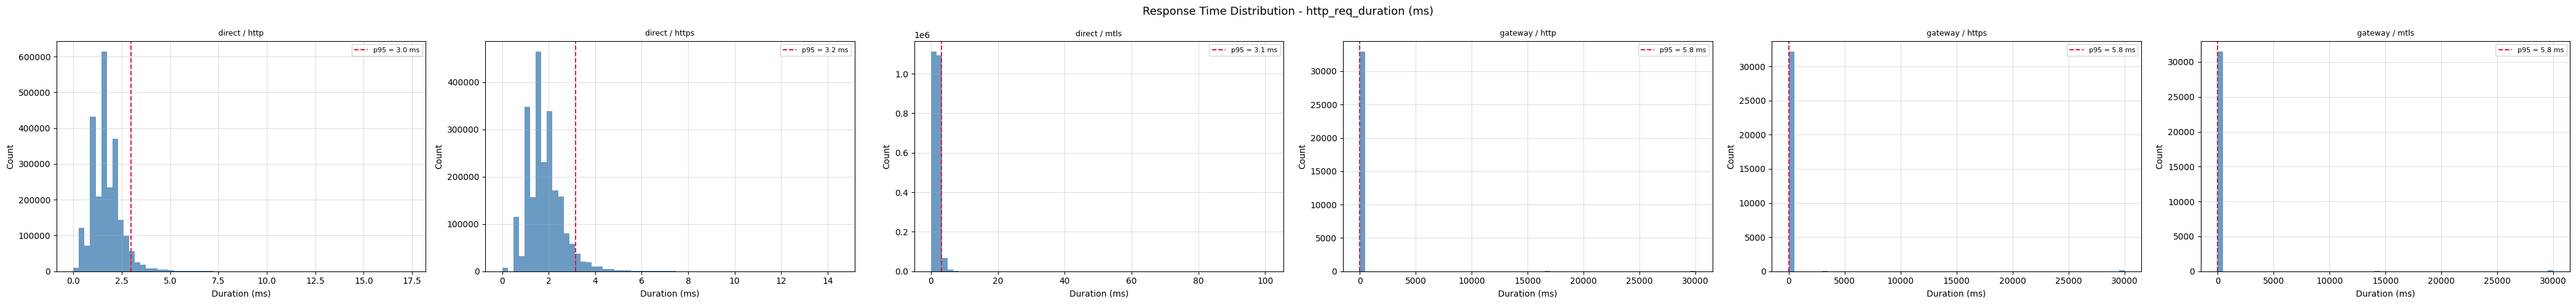

In [10]:
n = max(1, len(runs))
fig, axes = plt.subplots(1, n, figsize=(7 * n, 5), squeeze=False)
fig.suptitle("Response Time Distribution - http_req_duration (ms)", fontsize=13)

for ax, (label, df) in zip(axes[0], runs.items()):
    dur = get_metric(df, "http_req_duration")["value"].dropna()
    if dur.empty:
        ax.set_title(f"{label}\n(no data)")
        continue
    p95 = np.percentile(dur, 95)
    ax.hist(dur, bins=60, edgecolor="none", color="steelblue", alpha=0.8)
    ax.axvline(p95, color="crimson", linestyle="--", linewidth=1.4, label=f"p95 = {p95:.1f} ms")
    ax.set_xlabel("Duration (ms)")
    ax.set_ylabel("Count")
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Percentile Comparison

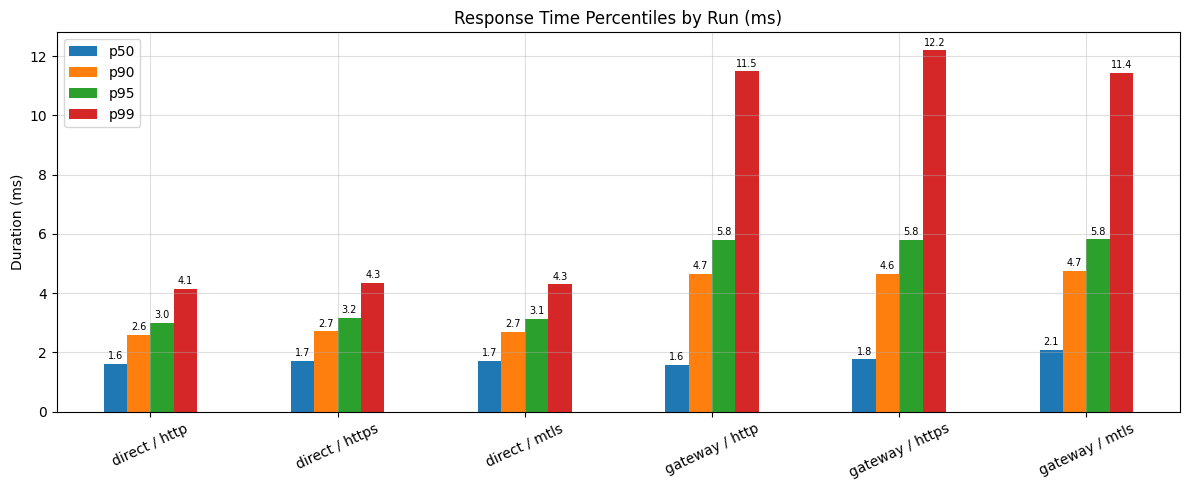

In [11]:
pct_rows = {}
for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")["value"].dropna()
    if dur.empty:
        continue
    pct_rows[label] = {
        "p50": np.percentile(dur, 50),
        "p90": np.percentile(dur, 90),
        "p95": np.percentile(dur, 95),
        "p99": np.percentile(dur, 99),
    }

if pct_rows:
    pct_df = pd.DataFrame(pct_rows).T
    ax = pct_df.plot(kind="bar", figsize=(max(8, 2 * len(pct_rows)), 5), rot=25)
    ax.set_title("Response Time Percentiles by Run (ms)")
    ax.set_ylabel("Duration (ms)")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", fontsize=7, padding=2)
    plt.tight_layout()
    plt.show()

## Response Time Over Time

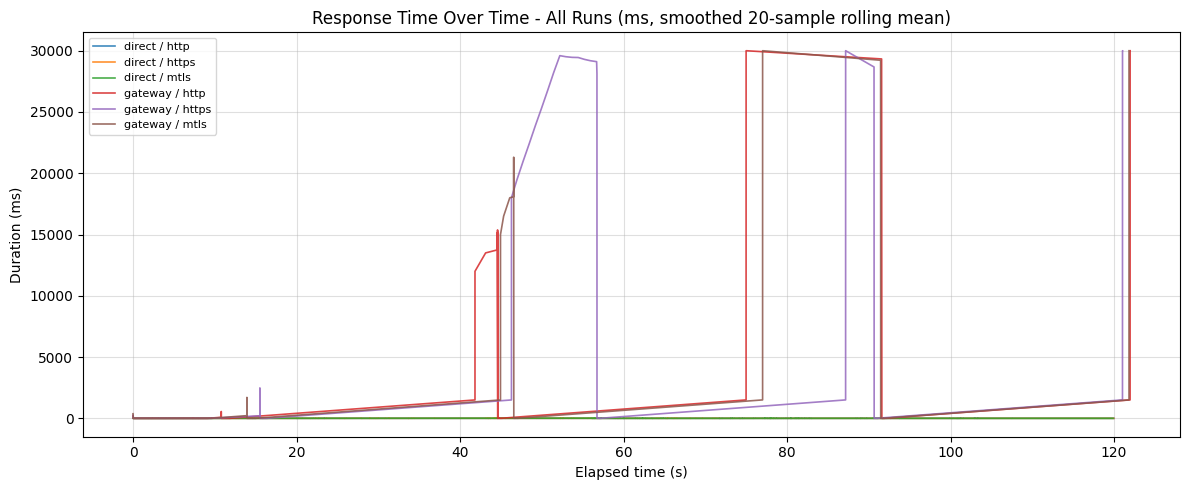

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")
    if dur.empty:
        continue
    ts = dur.set_index("time_sec")["value"].sort_index()
    smoothed = ts.rolling(window=20, min_periods=1).mean()
    ax.plot(smoothed.index, smoothed.values, label=label, linewidth=1.2, alpha=0.85)

ax.set_title("Response Time Over Time - All Runs (ms, smoothed 20-sample rolling mean)")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Duration (ms)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

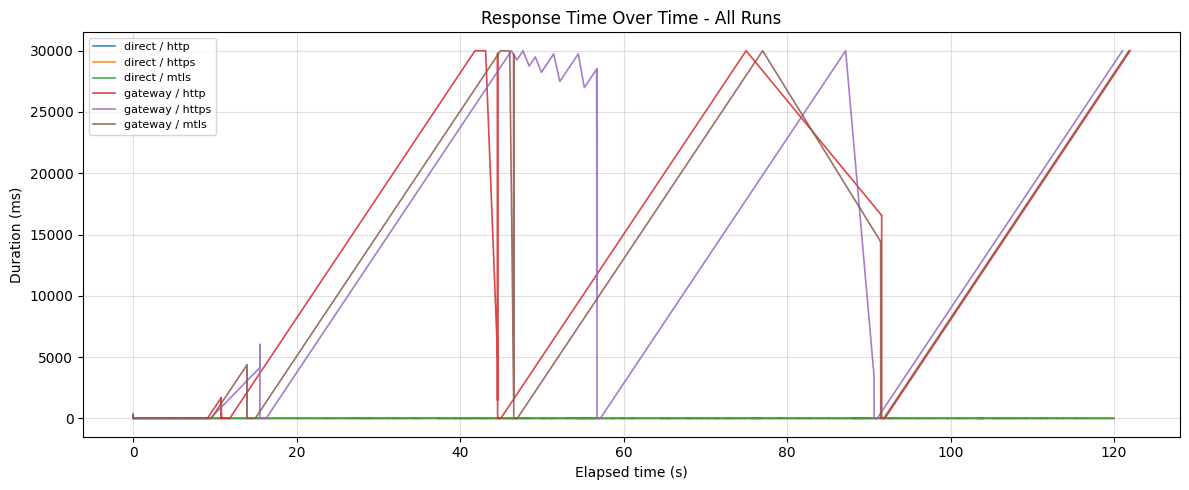

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, df in runs.items():
    
    dur = get_metric(df, "http_req_duration")

    ax.plot(dur["time_sec"], dur["value"] , label=label, linewidth=1.2, alpha=0.85)

ax.set_title("Response Time Over Time - All Runs")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Duration (ms)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

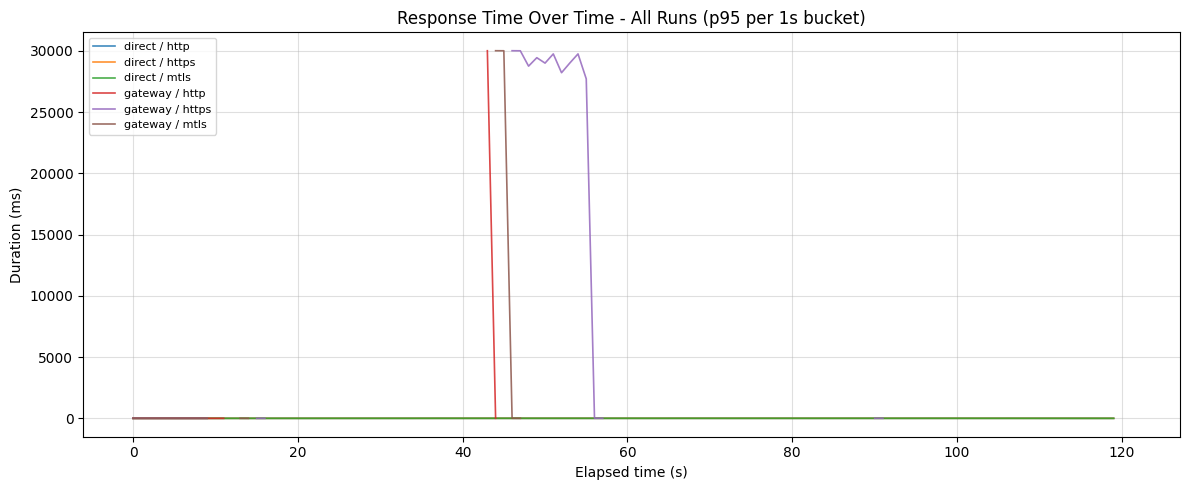

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")
    if dur.empty:
        continue

    ts = dur.set_index("time_sec")["value"].sort_index()

    # convert to consistent time bins (1s)
    ts.index = pd.to_timedelta(ts.index, unit="s")

    p95 = ts.resample("1s").quantile(0.95)

    ax.plot(
        p95.index.total_seconds(),
        p95.values,
        label=label,
        linewidth=1.2,
        alpha=0.85
    )

ax.set_title("Response Time Over Time - All Runs (p95 per 1s bucket)")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Duration (ms)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## TLS / Connection Timing Breakdown

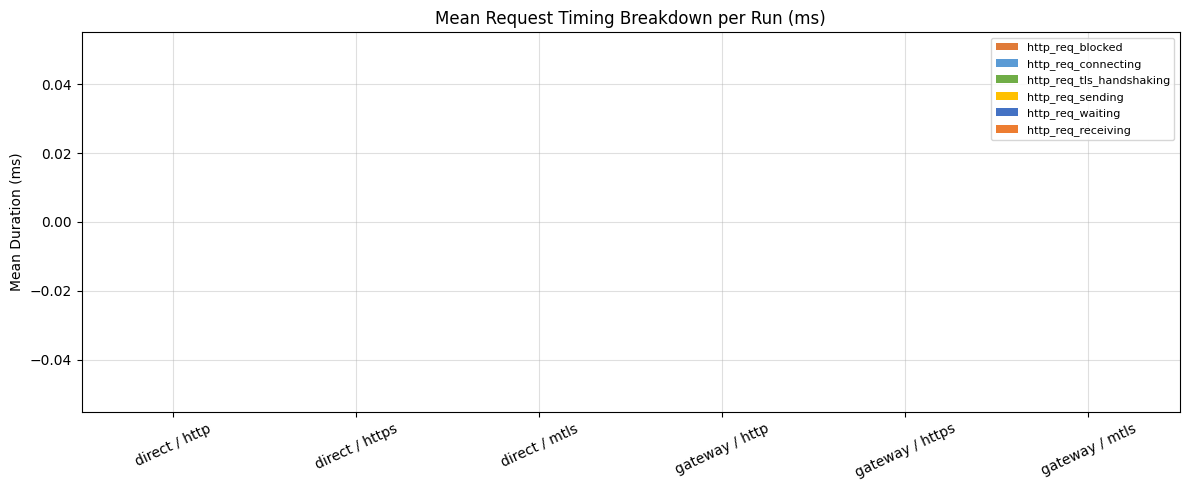

In [15]:
timing_metrics = [
    "http_req_blocked",
    "http_req_connecting",
    "http_req_tls_handshaking",
    "http_req_sending",
    "http_req_waiting",
    "http_req_receiving",
]
colors = ["#e07b39", "#5b9bd5", "#70ad47", "#ffc000", "#4472c4", "#ed7d31"]

timing_data = {}
for label, df in runs.items():
    row = {m: get_metric(df, m)["value"].dropna().mean() or 0 for m in timing_metrics}
    timing_data[label] = row

timing_df = pd.DataFrame(timing_data).T
timing_df.plot(kind="bar", stacked=True, figsize=(max(8, 2 * len(timing_data)), 5), color=colors, rot=25)
plt.title("Mean Request Timing Breakdown per Run (ms)")
plt.ylabel("Mean Duration (ms)")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Request Rate Over Time

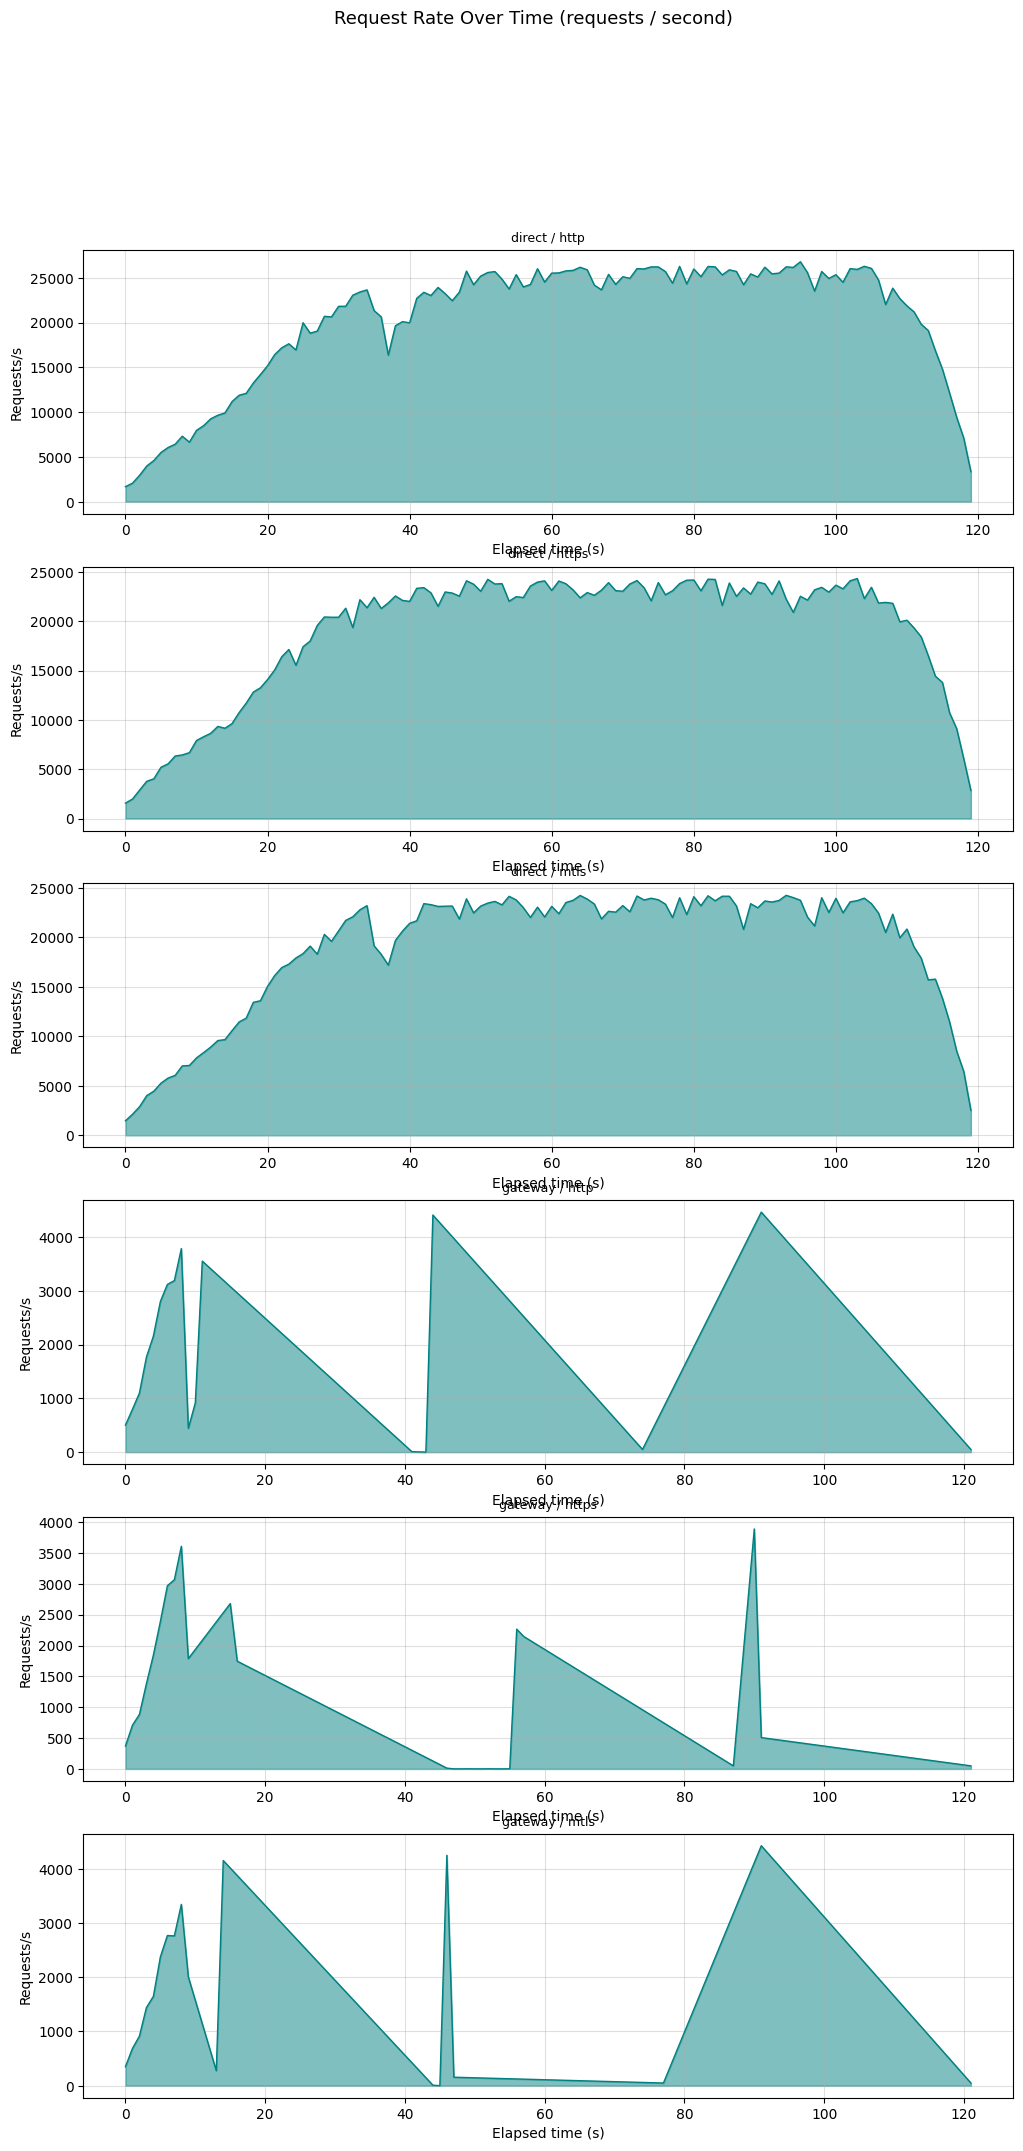

In [16]:
n = max(1, len(runs))
fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), squeeze=False)
fig.suptitle("Request Rate Over Time (requests / second)", fontsize=13)

for ax, (label, df) in zip(axes[:, 0], runs.items()):
    reqs = get_metric(df, "http_reqs").copy()
    if reqs.empty:
        ax.set_title(f"{label} - no data")
        continue
    reqs["bucket"] = reqs["time_sec"].astype(int)
    rate = reqs.groupby("bucket")["value"].sum()
    ax.fill_between(rate.index, rate.values, alpha=0.5, color="teal")
    ax.plot(rate.index, rate.values, color="teal", linewidth=1)
    ax.set_xlabel("Elapsed time (s)")
    ax.set_ylabel("Requests/s")
    ax.set_title(label, fontsize=9)

# plt.tight_layout()
plt.show()

## Check Pass Rate

In [17]:
check_rows = {}
for label, df in runs.items():
    checks = get_metric(df, "checks")
    if checks.empty:
        continue
    total = len(checks)
    passed = (checks["value"] == 1).sum()
    check_rows[label] = {
        "passed": int(passed),
        "failed": int(total - passed),
        "pass_rate_%": 100 * passed / total if total else 0,
    }

if check_rows:
    check_df = pd.DataFrame(check_rows).T
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    check_df[["passed", "failed"]].plot(kind="bar", ax=ax1, color=["#70ad47", "#e07b39"], rot=25)
    ax1.set_title("Check Results")
    ax1.set_ylabel("Count")

    ax2.bar(range(len(check_df)), check_df["pass_rate_%"], color="steelblue")
    ax2.set_xticks(range(len(check_df)))
    ax2.set_xticklabels(check_df.index, rotation=25, ha="right", fontsize=8)
    ax2.axhline(98, color="crimson", linestyle="--", linewidth=1.2, label="98% threshold")
    ax2.set_ylim(0, 102)
    ax2.set_ylabel("Pass Rate (%)")
    ax2.set_title("Check Pass Rate")
    ax2.legend(fontsize=8)
    for i, v in enumerate(check_df["pass_rate_%"]):
        ax2.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

## Per-Operation Breakdown

In [18]:
op_rows = []
for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")
    if "tags.operation" not in dur.columns:
        continue
    for op, grp in dur.groupby("tags.operation"):
        vals = grp["value"].dropna()
        if vals.empty:
            continue
        op_rows.append({
            "run": label,
            "operation": op,
            "p50": np.percentile(vals, 50),
            "p95": np.percentile(vals, 95),
            "p99": np.percentile(vals, 99),
        })

if op_rows:
    op_df = pd.DataFrame(op_rows)
    for pct in ["p50", "p95"]:
        pivot = op_df.pivot(index="run", columns="operation", values=pct)
        ax = pivot.plot(kind="bar", figsize=(max(8, 2 * len(pivot)), 5), rot=25)
        ax.set_title(f"{pct} Response Time per Operation (ms)")
        ax.set_ylabel("Duration (ms)")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f", fontsize=7, padding=2)
        plt.tight_layout()
        plt.show()
else:
    print("No per-operation data (only available for storage_direct_files / gateway_storage_files runs).")

No per-operation data (only available for storage_direct_files / gateway_storage_files runs).


## Multi-Run Percentile Comparison

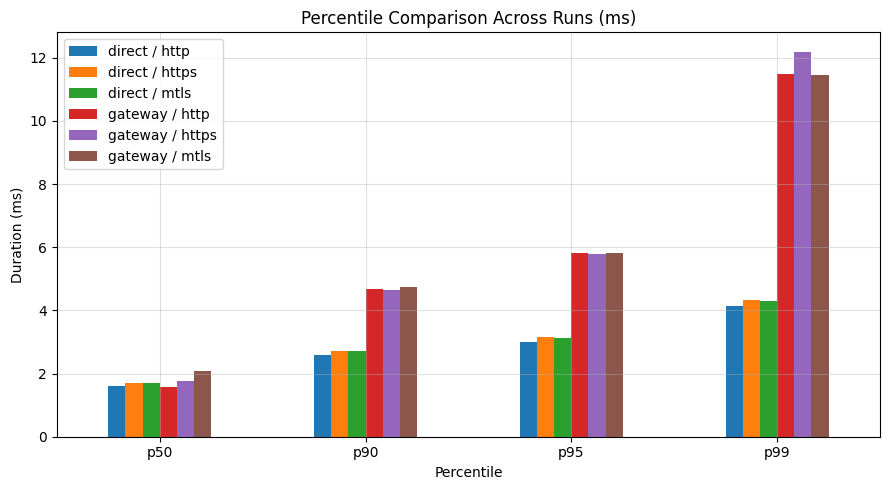

In [19]:
if len(pct_rows) > 1:
    pct_df2 = pd.DataFrame(pct_rows)  # columns = labels, rows = p50/p90/p95/p99
    ax = pct_df2.plot(kind="bar", figsize=(9, 5), rot=0)
    ax.set_title("Percentile Comparison Across Runs (ms)")
    ax.set_ylabel("Duration (ms)")
    ax.set_xlabel("Percentile")
    plt.tight_layout()
    plt.show()
else:
    print("Load at least 2 runs to see the multi-run comparison.")

In [20]:
get_metric(df, "http_reqs")

,time,value,metric,label,time_sec
0,2026-04-22 14:05:46.067747100+00:00,1.0,http_reqs,gateway / mtls,0.000000
2,2026-04-22 14:05:46.079385200+00:00,1.0,http_reqs,gateway / mtls,0.011638
4,2026-04-22 14:05:46.084150100+00:00,1.0,http_reqs,gateway / mtls,0.016403
6,2026-04-22 14:05:46.086740900+00:00,1.0,http_reqs,gateway / mtls,0.018994
8,2026-04-22 14:05:46.088815800+00:00,1.0,http_reqs,gateway / mtls,0.021069
...,...,...,...,...,...
63326,2026-04-22 14:07:47.898588100+00:00,1.0,http_reqs,gateway / mtls,121.830841
63328,2026-04-22 14:07:47.898588100+00:00,1.0,http_reqs,gateway / mtls,121.830841
63330,2026-04-22 14:07:47.898588100+00:00,1.0,http_reqs,gateway / mtls,121.830841
63332,2026-04-22 14:07:47.898588100+00:00,1.0,http_reqs,gateway / mtls,121.830841
